
Error vs Number of Shots
Shots	Theta=0.5625 Theta=0.1234
100	0.000000	0.126600
215	0.000000	0.126600
464	0.000000	0.126600
1000	0.000000	0.126600
2154	0.000000	0.126600
4641	0.000000	0.126600
10000	0.000000	0.126600
21544	0.000000	0.126600
46415	0.000000	0.126600
100000	0.000000	0.126600

Error vs Number of Ancilla Qubits
Ancilla	Theta=0.5625 Theta=0.1234
2	0.312500	0.123400
3	0.437500	0.376600
4	0.000000	0.126600
5	0.281250	0.001600


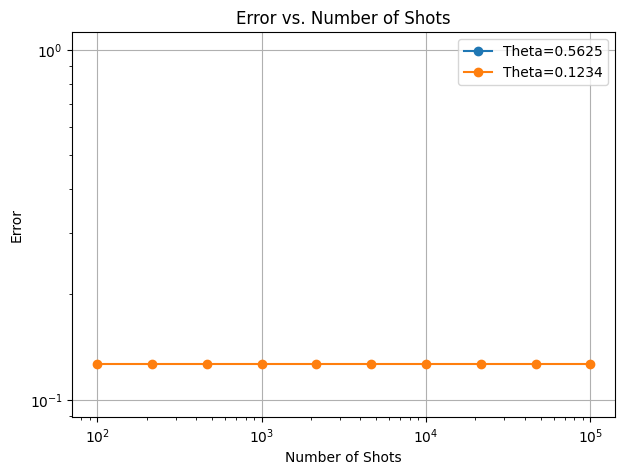

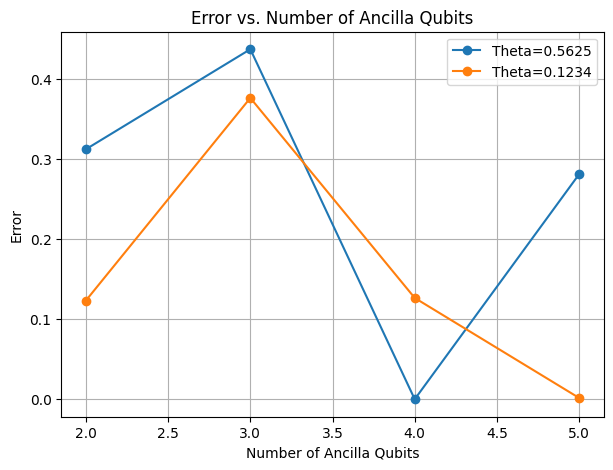

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import CPhaseGate
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler

def qft_dagger(n):
    """ Inverse Quantum Fourier Transform """
    qc = QuantumCircuit(n)
    for qubit in range(n//2):
        qc.swap(qubit, n-qubit-1)
    for j in reversed(range(n)):
        qc.h(j)
        for k in reversed(range(j)):
            qc.cp(-np.pi / (2 ** (j - k)), k, j)
    return qc

def qpe_circuit(theta, n_ancilla):
    """ Quantum Phase Estimation circuit """
    qpe = QuantumCircuit(n_ancilla + 1, n_ancilla)
    qpe.x(n_ancilla)  # Initialize target qubit to |1>
    
    for qubit in range(n_ancilla):
        qpe.h(qubit)
    
    for qubit in range(n_ancilla):
        qpe.append(CPhaseGate(2 * np.pi * theta * (2 ** (n_ancilla - qubit - 1))), [qubit, n_ancilla])
    
    qpe.append(qft_dagger(n_ancilla), range(n_ancilla))
    qpe.measure(range(n_ancilla), range(n_ancilla))
    return qpe

aer_sim = AerSimulator()

def run_qpe(theta, n_ancilla, num_shots):
    """ Run QPE and compute estimated phase error """
    qc = qpe_circuit(theta, n_ancilla)
    qc_transpiled = transpile(qc, backend=aer_sim, optimization_level=1)
    
    sampler = Sampler(aer_sim)
    result = sampler.run([qc_transpiled], shots=num_shots).result()
    counts = result[0].data.c.get_counts()
    
    max_count_key = max(counts, key=counts.get)
    theta_estimate = int(max_count_key, 2) / (2 ** n_ancilla)
    
    return abs(theta - theta_estimate)

theta_values = [0.5625, 0.1234]
num_shots_list = np.logspace(2, 5, num=10, dtype=int)
n_ancilla_list = [2, 3, 4, 5]

def print_error_table_shots():
    """ Print error table for varying number of shots """
    print("\nError vs Number of Shots")
    print("Shots", " ".join(f"Theta={theta}" for theta in theta_values), sep="\t")
    for num_shots in num_shots_list:
        errors = [run_qpe(theta, 4, num_shots) for theta in theta_values]
        print(num_shots, "\t".join(f"{error:.6f}" for error in errors), sep="\t")

def print_error_table_ancilla():
    """ Print error table for varying number of ancilla qubits """
    print("\nError vs Number of Ancilla Qubits")
    print("Ancilla", " ".join(f"Theta={theta}" for theta in theta_values), sep="\t")
    for n_ancilla in n_ancilla_list:
        errors = [run_qpe(theta, n_ancilla, 10000) for theta in theta_values]
        print(n_ancilla, "\t".join(f"{error:.6f}" for error in errors), sep="\t")

def plot_error_vs_shots():
    """ Plot error vs. number of shots """
    plt.figure(figsize=(7, 5))
    for theta in theta_values:
        errors = [run_qpe(theta, 4, shots) for shots in num_shots_list]
        plt.loglog(num_shots_list, errors, marker='o', label=f"Theta={theta}")
    plt.xlabel("Number of Shots")
    plt.ylabel("Error")
    plt.legend()
    plt.title("Error vs. Number of Shots")
    plt.grid(True)
    plt.show()

def plot_error_vs_ancilla():
    """ Plot error vs. number of ancilla qubits """
    plt.figure(figsize=(7, 5))
    for theta in theta_values:
        errors = [run_qpe(theta, n_ancilla, 10000) for n_ancilla in n_ancilla_list]
        plt.plot(n_ancilla_list, errors, marker='o', label=f"Theta={theta}")
    plt.xlabel("Number of Ancilla Qubits")
    plt.ylabel("Error")
    plt.legend()
    plt.title("Error vs. Number of Ancilla Qubits")
    plt.grid(True)
    plt.show()

# Run the analysis
print_error_table_shots()
print_error_table_ancilla()
plot_error_vs_shots()
plot_error_vs_ancilla()

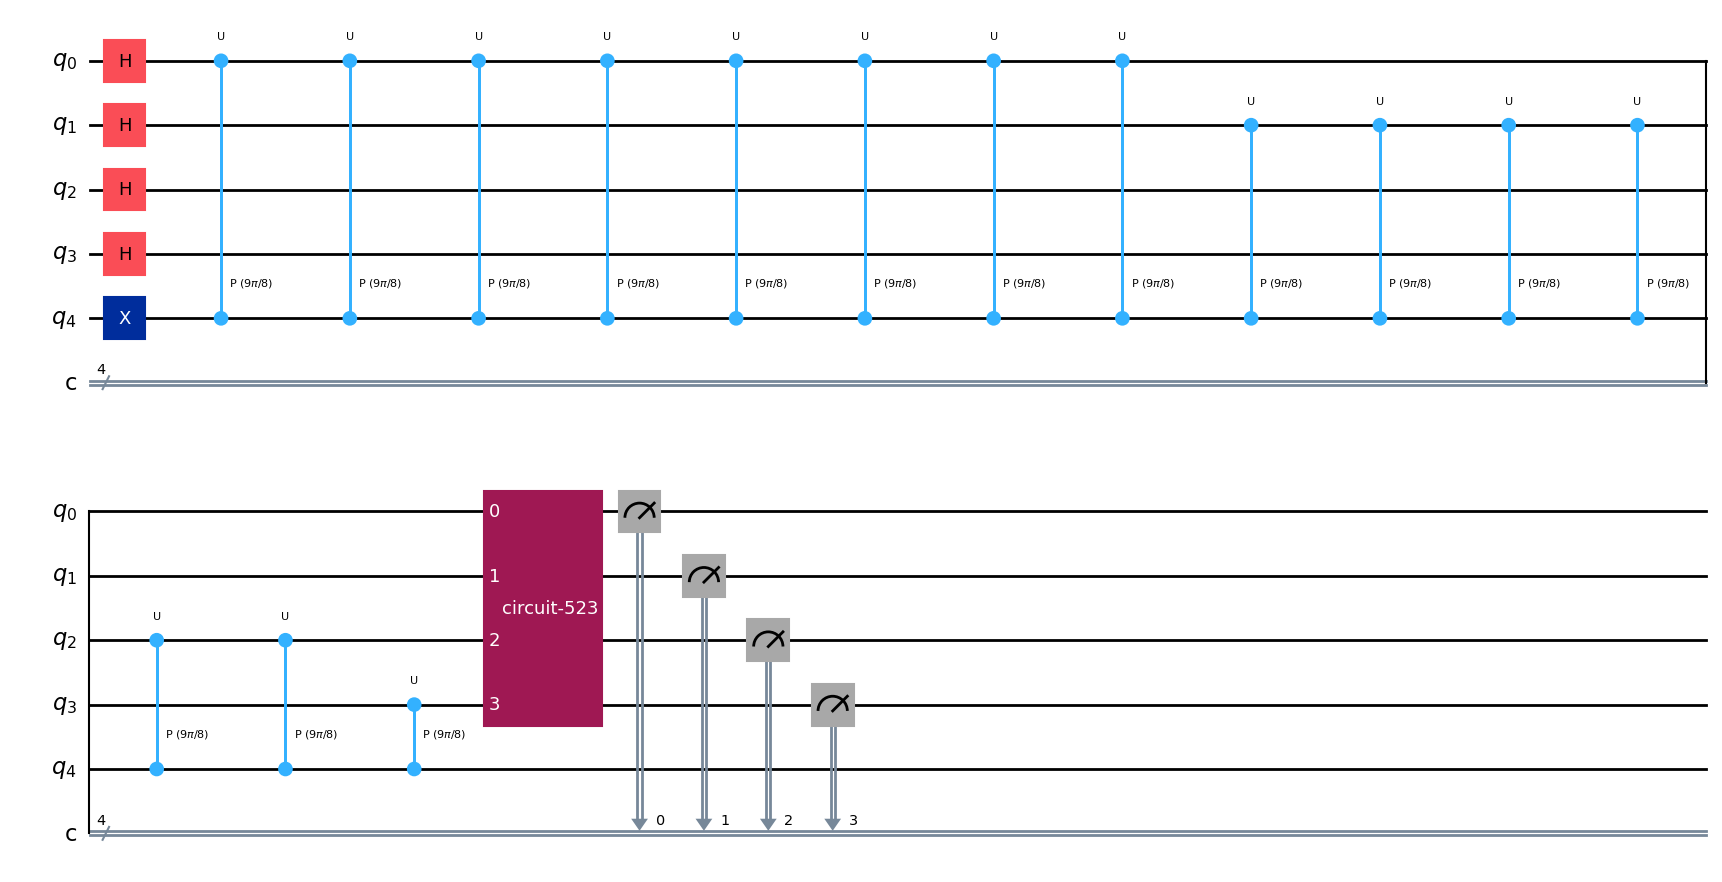

In [8]:
n_ancilla = 4
theta = 0.5625
"""
Quantum Phase Estimation (QPE) using Quantum Fourier Transform (QFT)
"""
qpe = QuantumCircuit(n_ancilla + 1, n_ancilla)
controlled_gate = CPhaseGate(2 * np.pi * theta, label='U')

# Initialize the last qubit to |1>
qpe.x(n_ancilla)

# Apply Hadamard gates to ancilla qubits
for qubit in range(n_ancilla):
    qpe.h(qubit)

# Apply controlled-U gates (Controlled Phase Gate)
for qubit in range(n_ancilla):
    for _ in range(2 ** (n_ancilla-qubit-1)):
        qpe.append(controlled_gate, [qubit, n_ancilla])

# Apply inverse QFT
qpe.append(qft_dagger(n_ancilla), range(n_ancilla))

# Measure ancilla qubits
qpe.measure(range(n_ancilla), range(n_ancilla))

qpe.draw('mpl') 
    


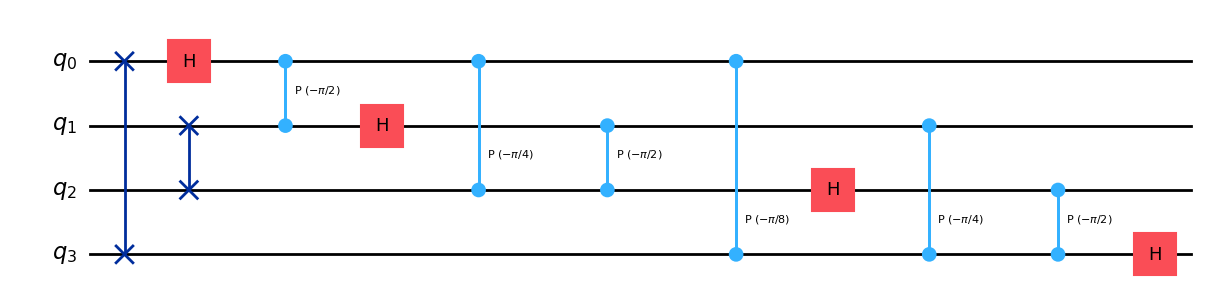

In [9]:
n=4
""" Inverse Quantum Fourier Transform """
qc = QuantumCircuit(n)
for qubit in range(n//2):
    qc.swap(qubit, n-qubit-1)
for j in range(n):
    for k in range(j):
        qc.cp(-np.pi/(2**(j-k)), k, j)
    qc.h(j)

qc.draw('mpl')